# Discriminator Evaluation — NPR & CommFor

Evaluates **ALL** images in configurable directories with two SOTA deepfake detectors:

1. **NPR** (CVPR 2024) — Neighboring Pixel Relationships, truncated ResNet50 (~6M params)
2. **CommFor** (CVPR 2025) — Community Forensics, ViT-Small trained on 4,803 generators

Results are merged by filename into existing CSVs that contain CLIP model predictions.

**Configurations** (6 total):
- Raw Input, SDXL Inpainted, Kandinsky Inpainted (1,000 images each)
- Raw Input PRNU, SDXL Inpainted PRNU, Kandinsky Inpainted PRNU (3,000 images each — 3 PRNU injection variants)

**Metrics** (threshold = 0.5, all images are fake):
- **Detection Rate (Accuracy)**: % of fake images correctly detected as fake
- **ASR (Attack Success Rate)**: % of images correctly detected in baseline that evade detection after inpainting (paired per-image; PRNU configs pair within same PRNU variant)
- **Confidence Reduction**: mean drop in fakeness score after inpainting (positive = less confident fake)

## 1. Setup

In [ ]:
!pip install -q timm torch torchvision pillow pandas tqdm matplotlib

from google.colab import drive
drive.mount('/content/drive')

import io
import os
import tarfile
from math import ceil
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Mounted at /content/drive
Device: cuda


## 2. Configuration

Update all placeholder paths below to match your Google Drive layout.

In [ ]:
# === WEIGHT PATHS ===
NPR_WEIGHTS_PATH = "/content/drive/MyDrive/commfor_and_npr_weights/weights/npr_pretrained.pth"
COMMFOR_WEIGHTS_TAR = "/content/drive/MyDrive/commfor_and_npr_weights/weights/commfor_weights.tar"
COMMFOR_CKPT_NAME = "pretrained_weights/model_v11_ViT_384_base_ckpt.pt"

# === IMAGE CONFIGURATIONS ===
# Each config: name, image_dir(s), csv_path (existing CLIP results), ground truth label.
# Use "image_dir" for a single directory, or "image_dirs" for multiple subdirectories.
# "baseline" (optional): name of the config to use as baseline for ASR computation.
CONFIGS = [
    # --- Non-PRNU configs ---
    {
        "name": "Raw Input",
        "image_dir": "/content/drive/MyDrive/impainting_input/input",
        "csv_path": "/content/drive/MyDrive/final_code_submission/5. Evaluation/impainting_input.csv",
        "label": "fake",
    },
    {
        "name": "SDXL Inpainted",
        "image_dir": "/content/drive/MyDrive/output_impainting_sdxl",
        "csv_path": "/content/drive/MyDrive/final_code_submission/5. Evaluation/output_impainting_sdxl.csv",
        "label": "fake",
        "baseline": "Raw Input",
    },
    {
        "name": "Kandinsky Inpainted",
        "image_dir": "/content/drive/MyDrive/output_inpainting_kandinsky",
        "csv_path": "/content/drive/MyDrive/final_code_submission/5. Evaluation/output_inpainting_kandinsky.csv",
        "label": "fake",
        "baseline": "Raw Input",
    },
    # --- PRNU-injected configs (3 subdirs each, 1000 images per subdir = 3000 total) ---
    {
        "name": "Raw Input PRNU",
        "image_dirs": [
            "/content/drive/MyDrive/output_raw_prnu/prnu_injected_additive",
            "/content/drive/MyDrive/output_raw_prnu/prnu_injected_dynamic_psnr",
            "/content/drive/MyDrive/output_raw_prnu/prnu_injected_scaled",
        ],
        "csv_path": "/content/drive/MyDrive/final_code_submission/5. Evaluation/output_raw_prnu.csv",
        "label": "fake",
    },
    {
        "name": "SDXL Inpainted PRNU",
        "image_dirs": [
            "/content/drive/MyDrive/output_impainting_sdxl_prnu/prnu_injected_additive",
            "/content/drive/MyDrive/output_impainting_sdxl_prnu/prnu_injected_dynamic_psnr",
            "/content/drive/MyDrive/output_impainting_sdxl_prnu/prnu_injected_scaled",
        ],
        "csv_path": "/content/drive/MyDrive/final_code_submission/5. Evaluation/output_impainting_sdxl_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input PRNU",
    },
    {
        "name": "Kandinsky Inpainted PRNU",
        "image_dirs": [
            "/content/drive/MyDrive/output_inpainting_kandinsky_prnu/prnu_injected_additive",
            "/content/drive/MyDrive/output_inpainting_kandinsky_prnu/prnu_injected_dynamic_psnr",
            "/content/drive/MyDrive/output_inpainting_kandinsky_prnu/prnu_injected_scaled",
        ],
        "csv_path": "/content/drive/MyDrive/final_code_submission/5. Evaluation/output_inpainting_kandinsky_prnu.csv",
        "label": "fake",
        "baseline": "Raw Input PRNU",
    },
]

THRESHOLD = 0.5
IMAGE_EXTENSIONS = {".jpeg", ".jpg", ".png"}

print(f"Configurations: {len(CONFIGS)}")
for c in CONFIGS:
    dirs = c.get("image_dirs", [c.get("image_dir", "")])
    print(f"  {c['name']}: {len(dirs)} dir(s), baseline={c.get('baseline', '—')}")

Configurations: 6
  Raw Input: 1 dir(s), baseline=—
  SDXL Inpainted: 1 dir(s), baseline=Raw Input
  Kandinsky Inpainted: 1 dir(s), baseline=Raw Input
  Raw Input PRNU: 3 dir(s), baseline=—
  SDXL Inpainted PRNU: 3 dir(s), baseline=Raw Input PRNU
  Kandinsky Inpainted PRNU: 3 dir(s), baseline=Raw Input PRNU


## 3. NPR Model Definition

In [ ]:
# --- NPR architecture (truncated ResNet50 with NPR forward pass) ---

def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)

def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = conv1x1(inplanes, planes)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = conv3x3(planes, planes, stride)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = conv1x1(planes, planes * self.expansion)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


class NPRResNet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, 3)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(512, num_classes)

    def _make_layer(self, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * Bottleneck.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * Bottleneck.expansion, stride),
                nn.BatchNorm2d(planes * Bottleneck.expansion),
            )
        layers = [Bottleneck(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * Bottleneck.expansion
        for _ in range(1, blocks):
            layers.append(Bottleneck(self.inplanes, planes))
        return nn.Sequential(*layers)

    @staticmethod
    def interpolate(img, factor):
        return F.interpolate(
            F.interpolate(img, scale_factor=factor, mode='nearest',
                          recompute_scale_factor=True),
            scale_factor=1.0 / factor, mode='nearest',
            recompute_scale_factor=True,
        )

    def forward(self, x):
        npr = x - self.interpolate(x, 0.5)
        x = self.conv1(npr * 2.0 / 3.0)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.fc1(x)


def translate_duplicate(img, crop_size=224):
    """Tile small images instead of resizing (avoids interpolation artifacts)."""
    if min(img.size) < crop_size:
        w, h = img.size
        new_w = w * ceil(crop_size / w)
        new_h = h * ceil(crop_size / h)
        new_img = Image.new('RGB', (new_w, new_h))
        for i in range(0, new_w, w):
            for j in range(0, new_h, h):
                new_img.paste(img, (i, j))
        return new_img
    return img


print("NPR architecture defined.")

NPR architecture defined.


## 4. CommFor Model Definition

In [ ]:
import timm

class ViTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = timm.create_model(
            "vit_small_patch16_384.augreg_in21k_ft_in1k", pretrained=False
        )
        self.vit.head = nn.Linear(384, 1)

    def forward(self, x):
        return self.vit(x)


print("CommFor architecture defined.")

CommFor architecture defined.


## 5. Load Models

In [ ]:
# --- Load NPR ---
print("Loading NPR...")
npr_model = NPRResNet(num_classes=1)
npr_sd = torch.load(NPR_WEIGHTS_PATH, map_location="cpu", weights_only=False)
npr_model.load_state_dict(npr_sd, strict=True)
npr_model.to(device).eval()

npr_transform = transforms.Compose([
    transforms.Lambda(lambda img: translate_duplicate(img, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print("NPR loaded.")

# --- Load CommFor ---
print("Loading CommFor...")
commfor_model = ViTClassifier()

with tarfile.open(COMMFOR_WEIGHTS_TAR) as tar:
    f = tar.extractfile(COMMFOR_CKPT_NAME)
    checkpoint = torch.load(io.BytesIO(f.read()), map_location="cpu", weights_only=False)

commfor_sd = checkpoint["model"]
if any(k.startswith("_orig_mod.") for k in commfor_sd):
    commfor_sd = {k.replace("_orig_mod.", ""): v for k, v in commfor_sd.items()}

commfor_model.load_state_dict(commfor_sd, strict=True)
commfor_model.to(device).eval()

commfor_transform = transforms.Compose([
    transforms.Resize(440, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print("CommFor loaded.")

print(f"\nBoth models loaded on {device}.")

Loading NPR...
NPR loaded.
Loading CommFor...
CommFor loaded.

Both models loaded on cuda.


## 6. Scoring Functions

In [ ]:
@torch.no_grad()
def get_fakeness_score(image_path, model, transform, device):
    """Returns sigmoid score in [0, 1]. Higher = more likely fake."""
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    logit = model(tensor)
    return torch.sigmoid(logit).item()


def score_to_prediction(score, threshold=0.5):
    """Convert fakeness score to (label_prediction, confident_score).

    Matches CLIP CSV convention: 0 = fake, 1 = real.
    confident_score = confidence in the predicted class.
    """
    if score > threshold:
        return 0, score        # predicted fake, confidence = score
    else:
        return 1, 1.0 - score  # predicted real, confidence = 1 - score


def evaluate_directory(image_dirs, model, transform, device):
    """Score ALL images in one or more directories.

    Args:
        image_dirs: single directory path (str) or list of directory paths.

    Returns: dict mapping filename -> (label_prediction, confident_score)
    """
    if isinstance(image_dirs, (str, Path)):
        image_dirs = [image_dirs]

    results = {}
    for image_dir in image_dirs:
        image_dir = Path(image_dir)
        image_files = sorted(
            f for f in image_dir.iterdir()
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
        )
        print(f"  Found {len(image_files)} images in {image_dir}")

        for img_path in tqdm(image_files, desc=f"  Scoring {image_dir.name}", leave=False):
            try:
                score = get_fakeness_score(str(img_path), model, transform, device)
                pred, conf = score_to_prediction(score, THRESHOLD)
                results[img_path.name] = (pred, conf)
            except Exception as e:
                print(f"    Error on {img_path.name}: {e}")

    return results


print("Scoring functions defined.")

Scoring functions defined.


## 7. Evaluate All Configurations

In [ ]:
all_results = {}  # config_name -> {"npr": {filename -> (pred, conf)}, "commfor": {...}}

for config in CONFIGS:
    name = config["name"]
    image_dirs = config.get("image_dirs", config.get("image_dir"))
    print(f"\n{'='*60}")
    print(f"Config: {name}")
    print(f"{'='*60}")

    print("\nNPR:")
    npr_results = evaluate_directory(image_dirs, npr_model, npr_transform, device)

    print("\nCommFor:")
    commfor_results = evaluate_directory(image_dirs, commfor_model, commfor_transform, device)

    all_results[name] = {"npr": npr_results, "commfor": commfor_results}
    print(f"\n  NPR scored: {len(npr_results)}, CommFor scored: {len(commfor_results)}")

print(f"\nAll {len(CONFIGS)} configurations evaluated.")


Config: Raw Input

NPR:
  Found 1000 images in /content/drive/MyDrive/impainting_input/input


  Scoring input:   0%|          | 0/1000 [00:00<?, ?it/s]


CommFor:
  Found 1000 images in /content/drive/MyDrive/impainting_input/input


  Scoring input:   0%|          | 0/1000 [00:00<?, ?it/s]


  NPR scored: 1000, CommFor scored: 1000

Config: SDXL Inpainted

NPR:
  Found 1000 images in /content/drive/MyDrive/output_impainting_sdxl


...

  Found 1000 images in /content/drive/MyDrive/output_inpainting_kandinsky_prnu/prnu_injected_dynamic_psnr


  Scoring prnu_injected_dynamic_psnr:   0%|          | 0/1000 [00:00<?, ?it/s]

  Found 1000 images in /content/drive/MyDrive/output_inpainting_kandinsky_prnu/prnu_injected_scaled


  Scoring prnu_injected_scaled:   0%|          | 0/1000 [00:00<?, ?it/s]


  NPR scored: 2905, CommFor scored: 2905

All 6 configurations evaluated.


## 8. Merge with Existing CSVs

In [ ]:
merged_dfs = {}  # config_name -> DataFrame

for config in CONFIGS:
    name = config["name"]
    csv_path = config["csv_path"]
    results = all_results[name]

    print(f"\n--- {name} ---")

    # Read existing CSV with CLIP results
    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    print(f"  Existing CSV: {len(df)} rows, columns: {list(df.columns)}")

    # Add NPR columns
    npr_preds, npr_confs = [], []
    for _, row in df.iterrows():
        fname = row["file_name"]
        if fname in results["npr"]:
            pred, conf = results["npr"][fname]
            npr_preds.append(pred)
            npr_confs.append(round(conf, 4))
        else:
            npr_preds.append(None)
            npr_confs.append(None)

    df["NPR_label_prediction"] = npr_preds
    df["NPR_confident_score"] = npr_confs

    # Add CommFor columns
    cf_preds, cf_confs = [], []
    for _, row in df.iterrows():
        fname = row["file_name"]
        if fname in results["commfor"]:
            pred, conf = results["commfor"][fname]
            cf_preds.append(pred)
            cf_confs.append(round(conf, 4))
        else:
            cf_preds.append(None)
            cf_confs.append(None)

    df["CommFor_label_prediction"] = cf_preds
    df["CommFor_confident_score"] = cf_confs

    # Count matches
    npr_matched = df["NPR_label_prediction"].notna().sum()
    cf_matched = df["CommFor_label_prediction"].notna().sum()
    print(f"  Matched: NPR={npr_matched}/{len(df)}, CommFor={cf_matched}/{len(df)}")

    merged_dfs[name] = df

print("\nMerge complete.")


--- Raw Input ---
  Existing CSV: 1000 rows, columns: ['file_name', 'path', 'CLIP_label_prediction', 'CLIP_confident_score', 'NPR_label_prediction', 'NPR_confident_score', 'CommFor_label_prediction', 'CommFor_confident_score']
  Matched: NPR=1000/1000, CommFor=1000/1000

--- SDXL Inpainted ---
  Existing CSV: 1000 rows, columns: ['file_name', 'path', 'CLIP_label_prediction', 'CLIP_confident_score', 'NPR_label_prediction', 'NPR_confident_score', 'CommFor_label_prediction', 'CommFor_confident_score']
  Matched: NPR=1000/1000, CommFor=1000/1000

--- Kandinsky Inpainted ---
  Existing CSV: 1000 rows, columns: ['file_name', 'path', 'CLIP_label_prediction', 'CLIP_confident_score', 'NPR_label_prediction', 'NPR_confident_score', 'CommFor_label_prediction', 'CommFor_confident_score']
  Matched: NPR=1000/1000, CommFor=1000/1000

--- Raw Input PRNU ---
  Existing CSV: 3000 rows, columns: ['file_name', 'path', 'CLIP_label_prediction', 'CLIP_confident_score']
  Matched: NPR=3000/3000, CommFor=3000

## 9. Compute Metrics

In [ ]:
import re

MODELS = {
    "CLIP": "CLIP_label_prediction",
    "NPR": "NPR_label_prediction",
    "CommFor": "CommFor_label_prediction",
}

PRNU_VARIANTS = ['additive', 'dynamic_psnr', 'scaled']


def strip_to_base_name(filename):
    """Strip inpainting and PRNU suffixes to get the original base filename.

    Handles case normalization (.PNG -> .png) to fix ADM image pairing.

    '012_biggan_00143_out_SDXL_spoofed_by_D07_Lenovo_P70A.png' -> '012_biggan_00143.png'
    '012_biggan_00143_out_Kandinsky.png' -> '012_biggan_00143.png'
    '012_biggan_00143_spoofed_by_D14_Apple_iPhone5c.png' -> '012_biggan_00143.png'
    '197_adm_7.PNG' -> '197_adm_7.png'
    """
    s = str(filename)
    s = re.sub(r'_spoofed_by_D\d+_[^.]+', '', s)
    s = re.sub(r'_out_[^.]+', '', s)
    return s.lower()


def extract_prnu_variant(path):
    """Extract PRNU injection variant from file path."""
    path_str = str(path)
    for variant in PRNU_VARIANTS:
        if f'prnu_injected_{variant}' in path_str:
            return variant
    return 'none'


def compute_detection_rate(df, label_col):
    """Detection rate (accuracy) — % of fake images predicted as fake (0)."""
    valid = df[label_col].dropna()
    if len(valid) == 0:
        return None
    return (valid == 0).sum() / len(valid)


def compute_asr(baseline_df, inpainted_df, label_col, use_prnu_variant=False):
    """Compute Attack Success Rate (paired per-image).

    ASR = (correctly detected in baseline AND misclassified after inpainting) /
          (correctly detected in baseline)

    For PRNU configs, matches on (base_name, prnu_variant) to ensure
    additive pairs with additive, etc.
    """
    raw = baseline_df[["file_name", label_col]].copy()
    raw["base_name"] = raw["file_name"].map(strip_to_base_name)

    inp = inpainted_df[["file_name", label_col]].copy()
    inp["base_name"] = inp["file_name"].map(strip_to_base_name)

    if use_prnu_variant and "path" in baseline_df.columns and "path" in inpainted_df.columns:
        raw["prnu_variant"] = baseline_df["path"].map(extract_prnu_variant)
        inp["prnu_variant"] = inpainted_df["path"].map(extract_prnu_variant)
        merge_keys = ["base_name", "prnu_variant"]
    else:
        merge_keys = ["base_name"]

    merged = raw[merge_keys + [label_col]].merge(
        inp[merge_keys + [label_col]],
        on=merge_keys, suffixes=("_raw", "_inp")
    )
    raw_col = f"{label_col}_raw"
    inp_col = f"{label_col}_inp"

    merged = merged.dropna(subset=[raw_col, inp_col])

    caught_raw = merged[merged[raw_col] == 0]
    if len(caught_raw) == 0:
        return None, 0, 0, len(merged)

    evaded = (caught_raw[inp_col] == 1).sum()
    asr = evaded / len(caught_raw)
    return asr, int(evaded), len(caught_raw), len(merged)


# --- Per-configuration metrics ---
summary_rows = []

# Show baseline detection rates
baselines_shown = set()
for config in CONFIGS:
    baseline_name = config.get("baseline")
    if baseline_name and baseline_name not in baselines_shown and baseline_name in merged_dfs:
        baselines_shown.add(baseline_name)
        print(f"\n{'='*60}")
        print(f"Baseline Detection Rates — {baseline_name}")
        print(f"{'='*60}")
        bdf = merged_dfs[baseline_name]
        for model_name, label_col in MODELS.items():
            if label_col not in bdf.columns:
                continue
            dr = compute_detection_rate(bdf, label_col)
            if dr is not None:
                n_detected = int(dr * bdf[label_col].notna().sum())
                print(f"  {model_name}: {dr*100:.2f}% ({n_detected}/{bdf[label_col].notna().sum()} detected as fake)")

# Detection rate + ASR per config
for config in CONFIGS:
    name = config["name"]
    df = merged_dfs[name]
    baseline_name = config.get("baseline")

    print(f"\n{'='*60}")
    print(f"{name} (all fake, n={len(df)})")
    print(f"{'='*60}")

    rows = []
    for model_name, label_col in MODELS.items():
        if label_col not in df.columns:
            continue

        det_rate = compute_detection_rate(df, label_col)

        # ASR only for configs with a baseline
        asr = None
        n_paired = 0
        evaded = 0
        caught = 0
        if baseline_name and baseline_name in merged_dfs:
            is_prnu = "PRNU" in name
            asr_val, evaded, caught, n_paired = compute_asr(
                merged_dfs[baseline_name], df, label_col, use_prnu_variant=is_prnu
            )
            asr = asr_val

        row = {
            "Model": model_name, "n": len(df),
            "Detection Rate": det_rate, "ASR": asr,
        }
        rows.append(row)
        summary_rows.append({"Config": name, **row})

        if baseline_name and n_paired > 0:
            print(f"  {model_name}: {n_paired} images paired, {caught} caught in raw, {evaded} evaded after inpainting")

    metrics_df = pd.DataFrame(rows).set_index("Model")
    display_df = metrics_df.copy()
    display_df["Detection Rate"] = display_df["Detection Rate"].map(
        lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A"
    )
    display_df["ASR"] = display_df["ASR"].map(
        lambda x: f"{x*100:.2f}%" if pd.notna(x) else "—"
    )
    print(display_df.to_string())

# --- Summary: Detection Rate ---
print(f"\n\n{'='*60}")
print("SUMMARY — Detection Rate (Accuracy)")
print(f"{'='*60}")
summary_df = pd.DataFrame(summary_rows)
pivot_dr = summary_df.pivot_table(
    index="Model", columns="Config", values="Detection Rate", aggfunc="first"
)
display_dr = pivot_dr.map(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A")
print(display_dr.to_string())

# --- Summary: ASR ---
asr_rows = [r for r in summary_rows if r["ASR"] is not None]
if asr_rows:
    print(f"\n{'='*60}")
    print("SUMMARY — Attack Success Rate (ASR)")
    print(f"{'='*60}")
    asr_df = pd.DataFrame(asr_rows)
    pivot_asr = asr_df.pivot_table(
        index="Model", columns="Config", values="ASR", aggfunc="first"
    )
    display_asr = pivot_asr.map(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A")
    print(display_asr.to_string())


Baseline Detection Rates — Raw Input
  CLIP: 88.70% (887/1000 detected as fake)
  NPR: 92.30% (923/1000 detected as fake)
  CommFor: 90.60% (906/1000 detected as fake)

Baseline Detection Rates — Raw Input PRNU
  CLIP: 86.40% (2592/3000 detected as fake)
  NPR: 79.60% (2388/3000 detected as fake)
  CommFor: 81.03% (2431/3000 detected as fake)

Raw Input (all fake, n=1000)
            n Detection Rate ASR
Model                           
CLIP     1000         88.70%   —
NPR      1000         92.30%   —
CommFor  1000         90.60%   —

SDXL Inpainted (all fake, n=1000)
  CLIP: 1000 images paired, 887 caught in raw, 30 evaded after inpainting
  NPR: 1000 images paired, 923 caught in raw, 0 evaded after inpainting
  CommFor: 1000 images paired, 906 caught in raw, 5 evaded after inpainting
            n Detection Rate    ASR
Model                              
CLIP     1000         87.60%  3.38%
NPR      1000        100.00%  0.00%
CommFor  1000         97.10%  0.55%

Kandinsky Inpainted (

## 9b. Confidence Reduction

Measures how much each detector's confidence that an image is fake drops after inpainting.

**Per image**: `reduction = fakeness_raw - fakeness_inpainted`
- Positive = inpainting made the image look less fake
- Negative = inpainting made the image look more fake (detector is more confident)

In [ ]:
CONF_COLS = {
    "CLIP": ("CLIP_label_prediction", "CLIP_confident_score"),
    "NPR": ("NPR_label_prediction", "NPR_confident_score"),
    "CommFor": ("CommFor_label_prediction", "CommFor_confident_score"),
}


def reconstruct_fakeness(df, label_col, conf_col):
    """Reconstruct raw fakeness score from (prediction, confident_score).

    If pred==0 (fake): fakeness = conf (score_to_prediction returned 0, score)
    If pred==1 (real): fakeness = 1 - conf (score_to_prediction returned 1, 1-score)
    """
    fakeness = df[conf_col].copy()
    real_mask = df[label_col] == 1
    fakeness[real_mask] = 1.0 - fakeness[real_mask]
    return fakeness


def compute_confidence_reduction(baseline_df, inpainted_df, label_col, conf_col,
                                  use_prnu_variant=False):
    """Compute per-image confidence reduction after inpainting.

    For PRNU configs, matches on (base_name, prnu_variant).
    """
    raw = baseline_df[["file_name", label_col, conf_col]].copy()
    raw["fakeness"] = reconstruct_fakeness(raw, label_col, conf_col)
    raw["base_name"] = raw["file_name"].map(strip_to_base_name)

    inp = inpainted_df[["file_name", label_col, conf_col]].copy()
    inp["fakeness"] = reconstruct_fakeness(inp, label_col, conf_col)
    inp["base_name"] = inp["file_name"].map(strip_to_base_name)

    if use_prnu_variant and "path" in baseline_df.columns and "path" in inpainted_df.columns:
        raw["prnu_variant"] = baseline_df["path"].map(extract_prnu_variant)
        inp["prnu_variant"] = inpainted_df["path"].map(extract_prnu_variant)
        merge_keys = ["base_name", "prnu_variant"]
    else:
        merge_keys = ["base_name"]

    merged = raw[merge_keys + ["fakeness"]].merge(
        inp[merge_keys + ["fakeness"]],
        on=merge_keys, suffixes=("_raw", "_inp")
    ).dropna()

    if len(merged) == 0:
        return None

    merged["reduction"] = merged["fakeness_raw"] - merged["fakeness_inp"]

    return {
        "n_paired": len(merged),
        "mean_reduction": merged["reduction"].mean(),
        "median_reduction": merged["reduction"].median(),
        "std_reduction": merged["reduction"].std(),
        "pct_reduced": (merged["reduction"] > 0).mean(),
        "mean_fakeness_raw": merged["fakeness_raw"].mean(),
        "mean_fakeness_inp": merged["fakeness_inp"].mean(),
    }


# --- Compute for each config that has a baseline ---
conf_reduction_rows = []

for config in CONFIGS:
    name = config["name"]
    baseline_name = config.get("baseline")
    if not baseline_name or baseline_name not in merged_dfs:
        continue

    print(f"\n{'='*60}")
    print(f"Confidence Reduction: {name} vs {baseline_name}")
    print(f"{'='*60}")

    is_prnu = "PRNU" in name
    rows = []
    for model_name, (label_col, conf_col) in CONF_COLS.items():
        if label_col not in merged_dfs[name].columns:
            continue
        result = compute_confidence_reduction(
            merged_dfs[baseline_name], merged_dfs[name], label_col, conf_col,
            use_prnu_variant=is_prnu
        )
        if result is None:
            print(f"  {model_name}: no paired images found")
            continue

        print(f"  {model_name}: {result['n_paired']} images paired")
        rows.append({
            "Model": model_name,
            "Mean Raw Fakeness": f"{result['mean_fakeness_raw']:.4f}",
            "Mean Inp Fakeness": f"{result['mean_fakeness_inp']:.4f}",
            "Mean Reduction": f"{result['mean_reduction']:+.4f}",
            "Median Reduction": f"{result['median_reduction']:+.4f}",
            "% Reduced": f"{result['pct_reduced']*100:.1f}%",
        })
        conf_reduction_rows.append({
            "Config": name, "Model": model_name, **result
        })

    if rows:
        print(pd.DataFrame(rows).set_index("Model").to_string())

# --- Summary ---
if conf_reduction_rows:
    print(f"\n\n{'='*60}")
    print("SUMMARY — Mean Confidence Reduction (positive = less confident fake)")
    print(f"{'='*60}")
    cr_df = pd.DataFrame(conf_reduction_rows)
    pivot_cr = cr_df.pivot_table(
        index="Model", columns="Config", values="mean_reduction", aggfunc="first"
    )
    display_cr = pivot_cr.map(lambda x: f"{x:+.4f}" if pd.notna(x) else "N/A")
    print(display_cr.to_string())


Confidence Reduction: SDXL Inpainted vs Raw Input
  CLIP: 1000 images paired
  NPR: 1000 images paired
  CommFor: 1000 images paired
        Mean Raw Fakeness Mean Inp Fakeness Mean Reduction Median Reduction % Reduced
Model                                                                                
CLIP               0.8570            0.8517        +0.0053          +0.0003     53.6%
NPR                0.9206            0.9992        -0.0786          +0.0000      1.4%
CommFor            0.9036            0.9667        -0.0631          +0.0000      9.9%

Confidence Reduction: Kandinsky Inpainted vs Raw Input
  CLIP: 1000 images paired
  NPR: 1000 images paired
  CommFor: 1000 images paired
        Mean Raw Fakeness Mean Inp Fakeness Mean Reduction Median Reduction % Reduced
Model                                                                                
CLIP               0.8570            0.8669        -0.0099          -0.0003     44.4%
NPR                0.9206            0.

## 10. Visualization

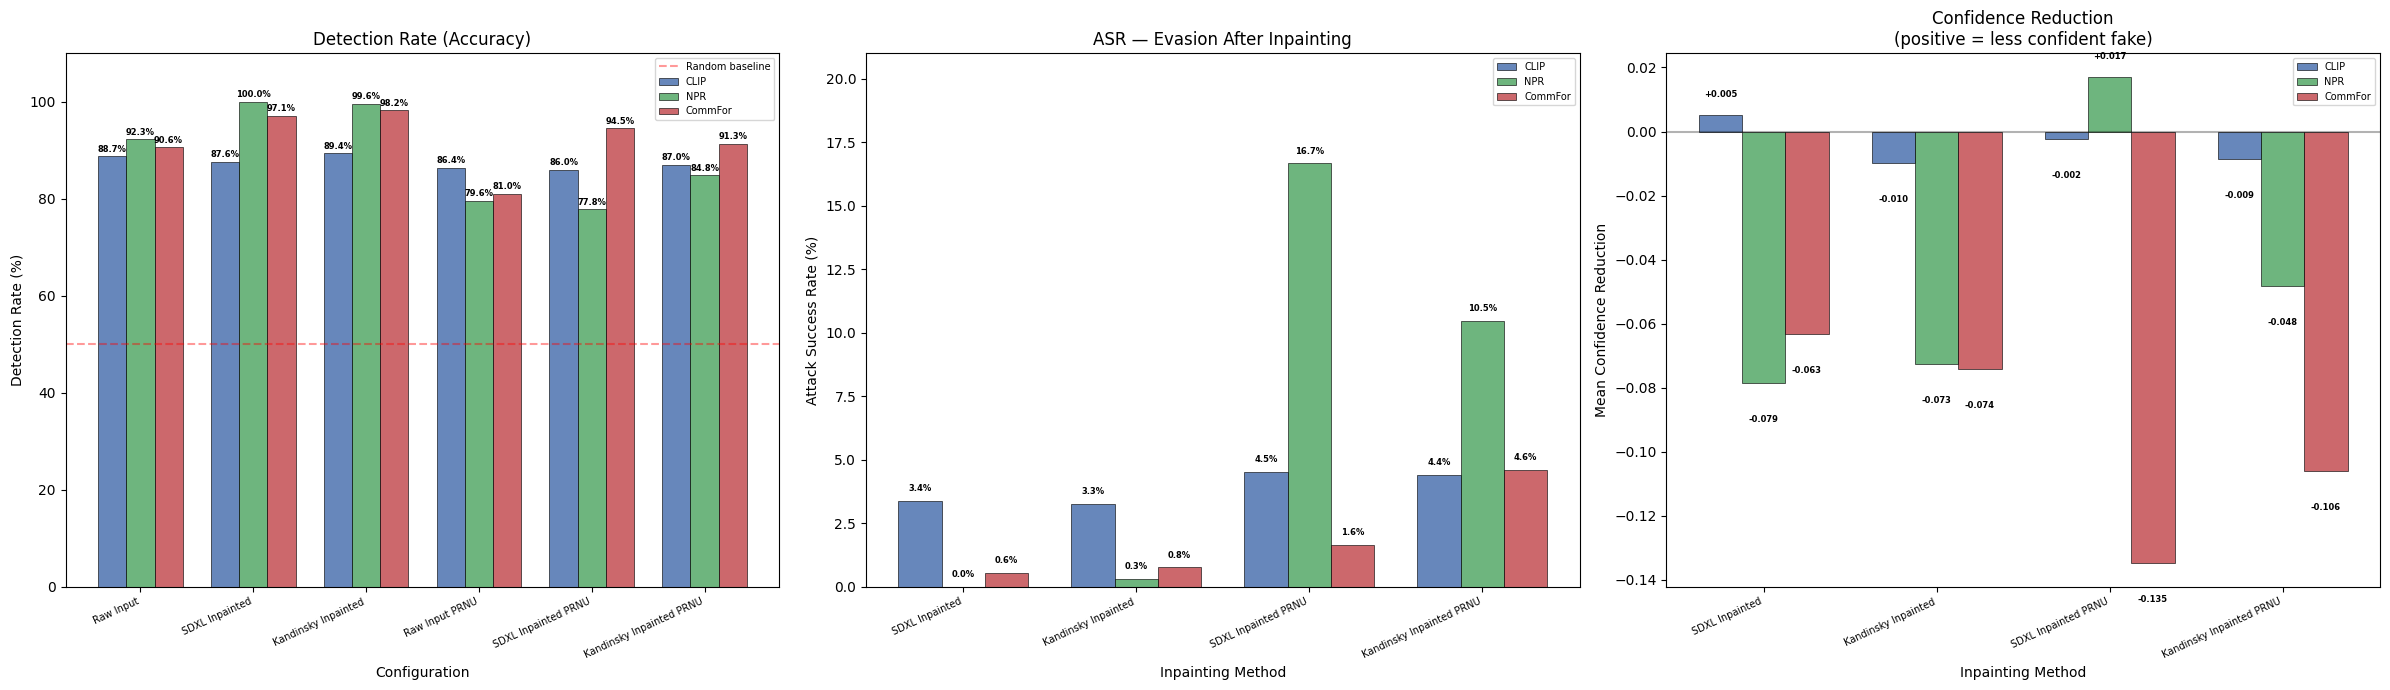

In [ ]:
config_names = [c["name"] for c in CONFIGS]
model_names = list(MODELS.keys())
colors = {"CLIP": "#4C72B0", "NPR": "#55A868", "CommFor": "#C44E52"}
inpaint_configs = [c["name"] for c in CONFIGS if c.get("baseline")]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
width = 0.25

# --- Left: Detection Rate (Accuracy) per config ---
x = range(len(config_names))

for i, model_name in enumerate(model_names):
    vals = []
    for cname in config_names:
        row = [r for r in summary_rows if r["Config"] == cname and r["Model"] == model_name]
        if row and row[0]["Detection Rate"] is not None:
            vals.append(row[0]["Detection Rate"] * 100)
        else:
            vals.append(0)
    offset = (i - len(model_names) / 2 + 0.5) * width
    bars = axes[0].bar([xi + offset for xi in x], vals, width, label=model_name,
                       color=colors.get(model_name, "gray"), alpha=0.85, edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val > 0:
            axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                         f"{val:.1f}%", ha="center", va="bottom", fontsize=6, fontweight="bold")

axes[0].axhline(y=50, color="red", linestyle="--", alpha=0.4, label="Random baseline")
axes[0].set_xlabel("Configuration")
axes[0].set_ylabel("Detection Rate (%)")
axes[0].set_title("Detection Rate (Accuracy)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(config_names, rotation=25, ha="right", fontsize=7)
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=7)

# --- Middle: ASR per inpainting config ---
x2 = range(len(inpaint_configs))

for i, model_name in enumerate(model_names):
    vals = []
    for cname in inpaint_configs:
        row = [r for r in summary_rows if r["Config"] == cname and r["Model"] == model_name]
        if row and row[0]["ASR"] is not None:
            vals.append(row[0]["ASR"] * 100)
        else:
            vals.append(0)
    offset = (i - len(model_names) / 2 + 0.5) * width
    bars = axes[1].bar([xi + offset for xi in x2], vals, width, label=model_name,
                       color=colors.get(model_name, "gray"), alpha=0.85, edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f"{val:.1f}%", ha="center", va="bottom", fontsize=6, fontweight="bold")

axes[1].set_xlabel("Inpainting Method")
axes[1].set_ylabel("Attack Success Rate (%)")
axes[1].set_title("ASR — Evasion After Inpainting")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(inpaint_configs, rotation=25, ha="right", fontsize=7)
axes[1].set_ylim(0, max(15, axes[1].get_ylim()[1] * 1.2))
axes[1].legend(fontsize=7)

# --- Right: Mean Confidence Reduction per inpainting config ---
x3 = range(len(inpaint_configs))

for i, model_name in enumerate(model_names):
    vals = []
    for cname in inpaint_configs:
        row = [r for r in conf_reduction_rows if r["Config"] == cname and r["Model"] == model_name]
        if row:
            vals.append(row[0]["mean_reduction"])
        else:
            vals.append(0)
    offset = (i - len(model_names) / 2 + 0.5) * width
    bars = axes[2].bar([xi + offset for xi in x3], vals, width, label=model_name,
                       color=colors.get(model_name, "gray"), alpha=0.85, edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        axes[2].text(bar.get_x() + bar.get_width() / 2,
                     val + (0.005 if val >= 0 else -0.01),
                     f"{val:+.3f}", ha="center", va="bottom" if val >= 0 else "top",
                     fontsize=6, fontweight="bold")

axes[2].axhline(y=0, color="black", linestyle="-", alpha=0.3)
axes[2].set_xlabel("Inpainting Method")
axes[2].set_ylabel("Mean Confidence Reduction")
axes[2].set_title("Confidence Reduction\n(positive = less confident fake)")
axes[2].set_xticks(x3)
axes[2].set_xticklabels(inpaint_configs, rotation=25, ha="right", fontsize=7)
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 11. Save Results

In [ ]:
for config in CONFIGS:
    name = config["name"]
    csv_path = config["csv_path"]
    df = merged_dfs[name]

    df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path} ({len(df)} rows, {len(df.columns)} columns)")

print("\nAll CSVs updated with NPR and CommFor results.")
print(f"Columns: {list(merged_dfs[CONFIGS[0]['name']].columns)}")

Saved: /content/drive/MyDrive/final_code_submission/5. Evaluation/impainting_input.csv (1000 rows, 8 columns)
Saved: /content/drive/MyDrive/final_code_submission/5. Evaluation/output_impainting_sdxl.csv (1000 rows, 8 columns)
Saved: /content/drive/MyDrive/final_code_submission/5. Evaluation/output_inpainting_kandinsky.csv (1000 rows, 8 columns)
Saved: /content/drive/MyDrive/final_code_submission/5. Evaluation/output_raw_prnu.csv (3000 rows, 8 columns)
Saved: /content/drive/MyDrive/final_code_submission/5. Evaluation/output_impainting_sdxl_prnu.csv (3000 rows, 8 columns)
Saved: /content/drive/MyDrive/final_code_submission/5. Evaluation/output_inpainting_kandinsky_prnu.csv (3000 rows, 8 columns)

All CSVs updated with NPR and CommFor results.
Columns: ['file_name', 'path', 'CLIP_label_prediction', 'CLIP_confident_score', 'NPR_label_prediction', 'NPR_confident_score', 'CommFor_label_prediction', 'CommFor_confident_score']
